In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()
# KGAT_6a0559d6033445e30d0c9f0daefc641b

Kaggle credentials set.
Kaggle credentials successfully validated.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

ucsc_cse_144_spring_2026_final_project_path = kagglehub.competition_download('ucsc-cse-144-spring-2026-final-project')

print('Data source import complete.')


100%|██████████| 120M/120M [00:08<00:00, 15.6MB/s]

Extracting files...


Data source import complete.


In [4]:
# Imports and Setup
import os, random
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets, models, io
from PIL import Image
from torchvision.transforms import v2 as tfv2
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.modules import pooling
from torch.nn.modules.pooling import MaxUnpool2d
import torch.optim as optim
import csv

device =  torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=42):
    ''' For reproducible results across runs '''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

In [5]:
# Load Training/Validation Data, transform, normalize, augment

data_dir = ucsc_cse_144_spring_2026_final_project_path + '/'
batch_size = 64
color_jitter_factor = 0.2
num_workers = 0 # for reproducibility
train_validation_ratio = 0.2
transforms = tfv2.Compose([
    tfv2.ToTensor(),
    tfv2.Resize((384,384), interpolation=tfv2.InterpolationMode.BILINEAR), # as reccomended by efficientnet v2 documentation
    # Augmentations
    tfv2.RandomHorizontalFlip(),        # Flip Horizontal
    tfv2.RandomRotation(degrees=15),    # Rotate randomly up to 15 degrees
    tfv2.ColorJitter(brightness=color_jitter_factor, saturation=color_jitter_factor), # adjust color
    tfv2.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

train_full = datasets.ImageFolder(root=data_dir+'train/', transform=transforms)
train_data, val_data = random_split(train_full, [1-train_validation_ratio, train_validation_ratio])
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print("train/val:", len(train_data), len(val_data))

train/val: 864 215


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [18]:
# Functions called for Training

def accuracy(loader, model):
    model.eval()
    correct = 0
    total = 0
    for data, label in loader:
        data, label = data.to(device), label.to(device)
        output = model(data)
        prediction=output.argmax(1)
        total += label.size(0)
        correct += prediction.eq(label.view_as(prediction)).sum().item()

    return 100 * correct / total

def run_one_epoch(loader, model, epoch, model_params):
    model.train()
    total_loss = 0.0

    # unfreezing layers
    if epoch % 5 == 0: # every 5 epochs, unfreeze 1 more layers
        model_params[-1].requires_grad = True
        model_params.pop(-1)

    for data, label in loader:
        data, label = data.to(device), label.to(device)
        optimizer.zero_grad() # reset optimizer gradients
        output = model(data)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    acc = accuracy(loader, model)
    return total_loss / len(loader), acc


In [11]:
# Validation Functions

def validate(loader, model):
    model.eval()
    total_loss = 0.0

    for data, label in loader:
        data, label = data.to(device), label.to(device)
        output = model(data)
        loss = criterion(output, label)
        total_loss += loss.item()

    acc = accuracy(loader, model)
    return total_loss / len(loader), acc

In [26]:
# Training and Validating
def one_train_val(fold, model, parameters, num_epochs=30):
    results = []
    train_losses, train_accs = [], []
    test_losses, test_accs  = [], []
    val_losses, val_accs = [], []
    best_val_acc = 0.0
    best_epoch = -1
    ckpt_path = "/content/drive/MyDrive/cse144_final_project_checkpoints/enetv2_l_best_" + str(fold)

    for epoch in range(num_epochs):
        train_loss, train_acc = run_one_epoch(loader=train_loader, model=model, epoch=epoch, model_params=parameters)
        val_loss, val_acc = validate(loader=val_loader,model=model)

        results.append(
            {
                "epoch": int(epoch),
                "train loss": round(float(train_loss), 4),
                "train acc": round(float(train_acc), 4),
                "val loss": round(float(val_loss), 4),
                "val acc": round(float(val_acc), 4),
            }
        )
        print(f"Epoch ({epoch})- Train Loss: {train_loss}, Train Acc: {train_acc}, Val Loss: {val_loss}, Val Acc: {val_acc}")

        if best_val_acc < val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            torch.save({'model_state_dict':model.state_dict(), 'epoch':epoch}, ckpt_path)

        torch.cuda.empty_cache()

    with open(f"/content/drive/MyDrive/cse144_final_project_checkpoints/csv/best_{fold}_results", "w") as f:
        writer = csv.DictWriter(f, fieldnames=['epoch', 'train loss', 'train acc', 'val loss', 'val acc'])
        writer.writeheader()
        writer.writerows(results)

    return best_val_acc

In [27]:
# Hyperparameter Tuning

num_classes= 100
best_val_acc = -1
best_param = 0.0

for i, dpr in enumerate([0.3, 0.5]):

    # Load pre-trained model
    base_model = models.efficientnet_v2_l(weights='DEFAULT')
    num_ftrs = base_model.classifier[1].in_features

    # refresh parameters list
    parameters = list(base_model.parameters())
    # freeze layers
    for param in parameters:
        param.requires_grad = False

    # Load optimizers and criterion
    optimizer = optim.Adam(base_model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss() # cross entropy loss for classification

    base_model.classifier[1] = nn.Sequential(
                                            nn.Dropout(p=dpr, inplace=True), # Hyperparameters: p=0.2
                                            nn.Linear(in_features=num_ftrs, out_features=num_classes), # output resized to fit our dataset
                                            )

    base_model = base_model.to(device)
    val_acc = one_train_val(fold=i, model=base_model, parameters=parameters, num_epochs=100)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_param = dpr



Epoch (0)- Train Loss: 4.817260912486485, Train Acc: 0.9259259259259259, Val Loss: 4.650843501091003, Val Acc: 1.3953488372093024
Epoch (1)- Train Loss: 4.797977243150983, Train Acc: 1.0416666666666667, Val Loss: 4.668530583381653, Val Acc: 1.3953488372093024
Epoch (2)- Train Loss: 4.814778975078037, Train Acc: 1.0416666666666667, Val Loss: 4.658283472061157, Val Acc: 1.8604651162790697
Epoch (3)- Train Loss: 4.775613307952881, Train Acc: 0.6944444444444444, Val Loss: 4.678225040435791, Val Acc: 1.3953488372093024
Epoch (4)- Train Loss: 4.849771669932774, Train Acc: 1.2731481481481481, Val Loss: 4.654700756072998, Val Acc: 0.46511627906976744
Epoch (5)- Train Loss: 4.811687707901001, Train Acc: 0.8101851851851852, Val Loss: 4.661753058433533, Val Acc: 1.3953488372093024
Epoch (6)- Train Loss: 4.800022874559675, Train Acc: 1.1574074074074074, Val Loss: 4.666254997253418, Val Acc: 1.3953488372093024
Epoch (7)- Train Loss: 4.800760848181588, Train Acc: 1.0416666666666667, Val Loss: 4.6543

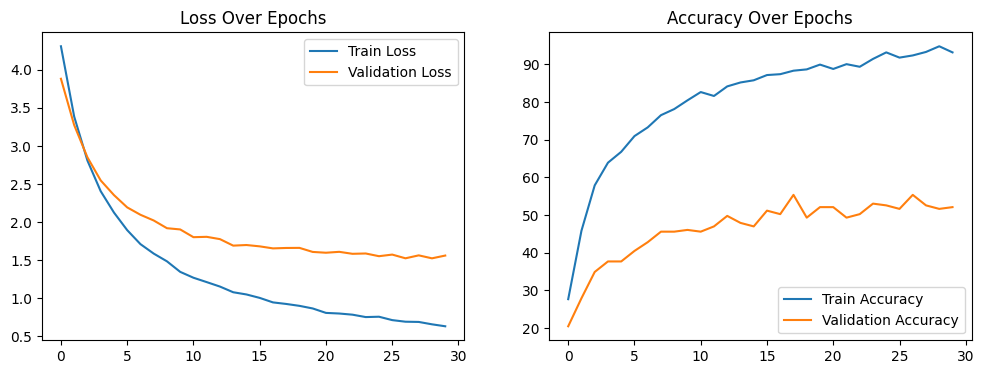

In [ ]:
# Plot loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss Over Epochs')
plt.legend()

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()

plt.show()

In [ ]:
class TestSet(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(os.listdir(self.root_dir))

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_id = f"{idx}.jpg"
        img_path = os.path.join(self.root_dir, img_id)
        sample = Image.open(img_path)

        if self.transform:
            sample = self.transform(sample)

        return sample, img_id


In [ ]:
# Testing, save results as .csv file with imgID | class
import csv
ckpt_path = "/content/drive/MyDrive/cse144_final_project_checkpoints/best_2"
data_dir = ucsc_cse_144_spring_2026_final_project_path + '/'
num_classes = 100

# Load the model
model = models.efficientnet_v2_s(weights='DEFAULT')
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(nn.Dropout(p=0.2, inplace=True),
                                        nn.Linear(in_features=num_ftrs, out_features=num_classes) # output resized to fit our dataset
                                        )
model = model.to(device)

state_dict = torch.load(ckpt_path, map_location='cpu')['model_state_dict']
model.load_state_dict(state_dict)
model.eval()

num_workers = 0
test_transforms = tfv2.Compose([
    tfv2.ToTensor(),
    tfv2.Resize((384,384), interpolation=tfv2.InterpolationMode.BILINEAR), # as reccomended by efficientnet v2 documentation
    tfv2.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

test_set = TestSet(root_dir=data_dir+'test', transform=test_transforms)
test_loader = DataLoader(test_set, batch_size=1, num_workers=num_workers, shuffle=False)

with open('submission.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['ID', 'Label']) # HEADER
    with torch.no_grad():
        for input, id in test_loader:
            input = input.to(device)
            id = id[0]
            output = model(input)
            writer.writerow([id, torch.argmax(output, dim=1).item()])
